In [ ]:
TOPICS = {
    "Reverse Engineering": [
        "reverse engineering","re-engineer","reengineer",
        "model recovery","design recovery","architecture recovery",
        "requirements recovery","software visualization","program comprehension",
    ],
    "OO": [
        "object-oriented","object oriented","OO","OOP",
        "object-oriented software","class-based","inheritance","polymorphism"
    ],
    "Code": [
        "legacy system","code base","source code"
    ],
    "UML/Use Cases": [
        "uml","class diagram","sequence diagram","object diagram","state machine",
        "package diagram","component diagram","activity diagram",
        "interaction diagram","collaboration diagram",
        "use case","use-case","use case diagram","scenario"
    ],
    "Static Analysis": [
        "static analysis","source code analysis","ast","call graph",
        "dependency analysis","points-to analysis","control flow analysis",
        "software metrics","code inspection"
    ],
    "Concept/Feature Location & IR": [
        "concept location","feature location","concern location",
        "information retrieval","ir","traceability",
        "requirements traceability","requirements extraction",
        "latent semantic indexing","lsi","topic modeling"
    ],
    "NLP/ML": [
        "natural language processing","nlp","bert","llm","language model",
        "word embeddings","topic model","transformer"
    ],
}

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import itertools

valid_keywords = [k for k in df_clean["keywords"] if isinstance(k, list)]
flat_keywords = list(itertools.chain.from_iterable(valid_keywords)) 
keyword_counts = Counter(flat_keywords)

most_common = keyword_counts.most_common(15)
labels, counts = zip(*most_common)

plt.figure(figsize=(12, 7))
plt.barh(labels[::-1], counts[::-1], color='skyblue')
plt.xlabel("Frequência")
plt.title("Top 15 Palavras-chave Mais Frequentes")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


In [57]:
import os
import pickle
import pandas as pd
from dataclasses import asdict

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import hdbscan
import re
import unicodedata

In [53]:
def extract_researches_results(rot_dir: str | os.PathLike): 
    researches = []
    for papers in os.listdir(rot_dir):
        researches_results_path = os.path.join(rot_dir, papers)
        with open(researches_results_path, "rb") as file: 
            research = asdict(pickle.load(file))
            researches.append(research)
    return researches

def extract_papers(researches : list[dict]):            
    papers = []
    for results in researches:
        for paper in results["papers"].values():
            papers.append(paper)
    return papers

In [ ]:
dir_acm_path = os.path.join("papers", "acm")
dir_ieee_path = os.path.join("papers", "ieee")
    
researches_acm = extract_papers(extract_researches_results(dir_acm_path))
researches_ieee = extract_papers(extract_researches_results(dir_ieee_path))

researches = researches_acm
researches.extend(researches_ieee)


df = pd.DataFrame(researches)
df_clean = df.drop_duplicates(subset="DOI", keep="first").reset_index(drop=True)
#df_clean = df.drop_duplicates(subset="title", keep="first").reset_index(drop=True)

valid_keywords = [k for k in df_clean["keywords"] if isinstance(k, list)]
flat_keywords = list(itertools.chain.from_iterable(valid_keywords)) 
keyword_counts = Counter(flat_keywords)

data = dict(keyword_counts) 
df_kw = pd.DataFrame(list(data.items()), columns=["keyword", "count"])

model = SentenceTransformer("all-MiniLM-L6-v2")
X = model.encode(df_kw["keyword"])
Xn = normalize(X)

clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric="euclidean")
df_kw["cluster"] = clusterer.fit_predict(X)

clusters = (
    df_kw.groupby("cluster")["keyword"]
         .apply(list)
         .to_dict()
)

_punct_tbl = str.maketrans("", "", r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~""")

def _norm_token(s: str) -> str:
    s = unicodedata.normalize("NFKC", s).lower().strip()
    s = s.translate(_punct_tbl)
    s = re.sub(r"\s+", " ", s)
    return s

def _to_token_set(words):
    if not isinstance(words, (list, tuple, set)):
        return set()
    return { _norm_token(w) for w in words if isinstance(w, str) and w.strip() }

def label_topics(keywords: list[str], clusters_dict: dict[int, list[str]]):
    keyset = _to_token_set(keywords)
    hits = []
    for cid, terms in clusters_dict.items():
        termset = _to_token_set(terms)
        if keyset & termset:  
            hits.append(cid)
    return hits or ["Other"]

df_papers = pd.DataFrame(researches)

df_clean = df_papers.drop_duplicates(subset="DOI", keep="first").reset_index(drop=True)

df_clean["topic_ids"] = df_clean["keywords"].apply(lambda ks: label_topics(ks, clusters))

/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


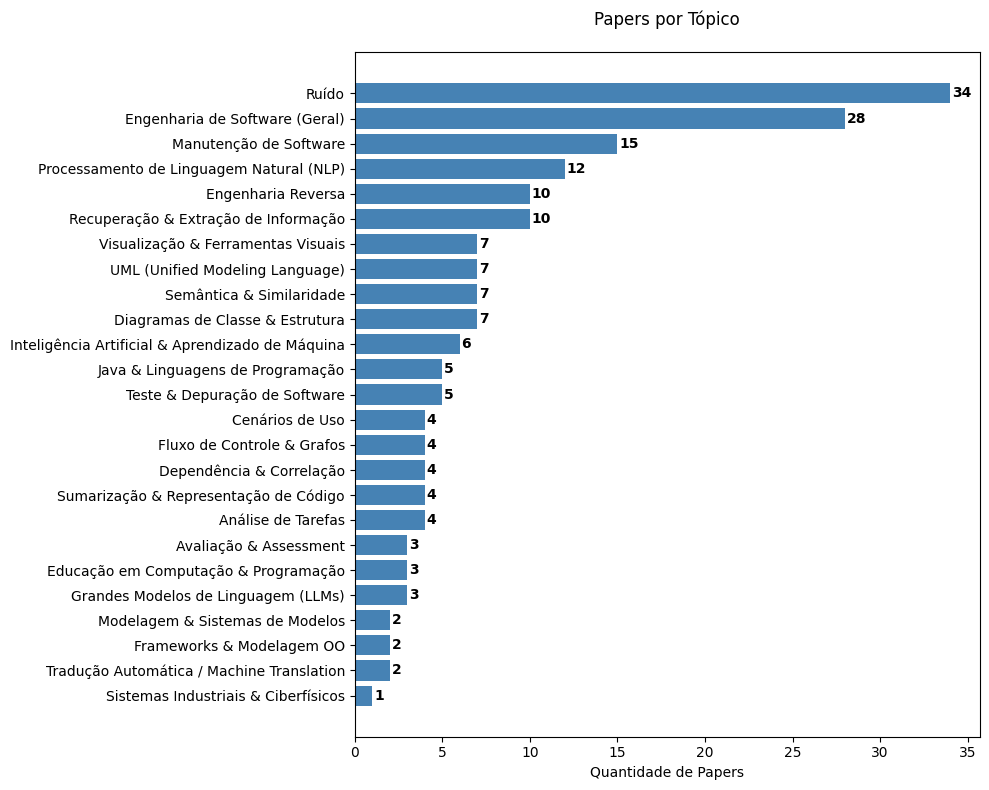

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
cluster_names = {
    -1:  "Ruído",
    0:   "Dependência & Correlação",
    1:   "Cenários de Uso",
    2:   "Fluxo de Controle & Grafos",
    3:   "Diagramas de Classe & Estrutura",
    4:   "Avaliação & Assessment",
    5:   "Recuperação & Extração de Informação",
    6:   "Análise de Tarefas",
    7:   "Teste & Depuração de Software",
    8:   "Tradução Automática / Machine Translation",
    9:   "Sistemas Industriais & Ciberfísicos",
    10:  "Frameworks & Modelagem OO",
    11:  "Semântica & Similaridade",
    12:  "Engenharia Reversa",
    13:  "Visualização & Ferramentas Visuais",
    14:  "Inteligência Artificial & Aprendizado de Máquina",
    15:  "Manutenção de Software",
    16:  "Processamento de Linguagem Natural (NLP)",
    17:  "Grandes Modelos de Linguagem (LLMs)",
    18:  "Modelagem & Sistemas de Modelos",
    19:  "UML (Unified Modeling Language)",
    20:  "Engenharia de Software (Geral)",
    21:  "Educação em Computação & Programação",
    22:  "Sumarização & Representação de Código",
    23:  "Java & Linguagens de Programação"
}

tp = df_clean.explode("topic_ids", ignore_index=True)

tp = tp[tp["topic_ids"] != "Other"]

topic_counts = (
    tp.groupby("topic_ids")
      .size()
      .rename("n")
      .reset_index()
)

topic_counts["topic_name"] = topic_counts["topic_ids"].map(cluster_names)

topic_counts = topic_counts.sort_values("n", ascending=True)

plt.figure(figsize=(10, 8))
ax = plt.gca()

bars = ax.barh(topic_counts["topic_name"], topic_counts["n"], color="steelblue")

plt.title("Papers por Tópico", pad=20)
plt.xlabel("Quantidade de Papers")

# Adiciona rótulos no fim das barras
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1,                        # posição X (um pouco depois do fim)
        bar.get_y() + bar.get_height() / 2, # posição Y (meio da barra)
        f"{width:.0f}",                     # texto (sem casas decimais)
        va="center", ha="left", fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.show()



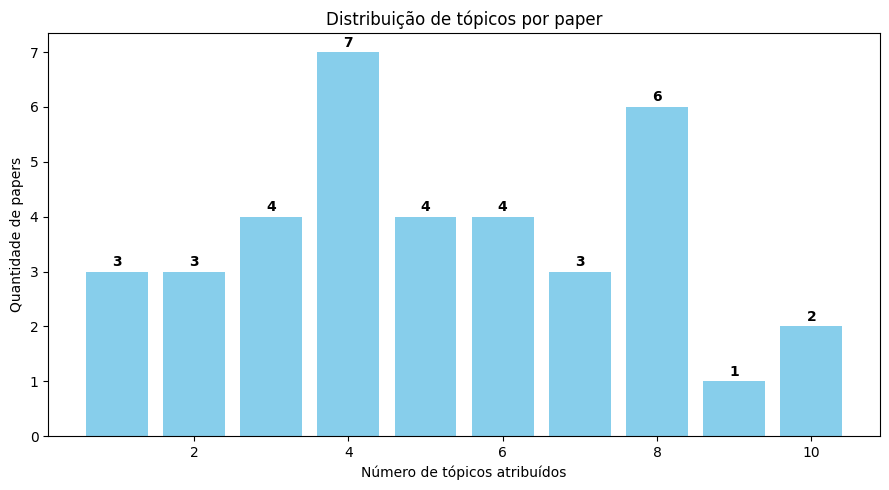

In [98]:
import matplotlib.pyplot as plt

# Conta quantos tópicos cada paper tem
df_clean["num_topics"] = df_clean["topic_ids"].apply(len)

# Distribuição
topic_dist = df_clean["num_topics"].value_counts().sort_index()

# Gráfico de barras
plt.figure(figsize=(9,5))
plt.bar(topic_dist.index, topic_dist.values, color="skyblue")

plt.title("Distribuição de tópicos por paper")
plt.xlabel("Número de tópicos atribuídos")
plt.ylabel("Quantidade de papers")

# rótulos em cima das barras
for i, v in enumerate(topic_dist.values):
    plt.text(topic_dist.index[i], v + 0.1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()



In [99]:
from itertools import combinations

# cria dicionário {paper_index: set(topics)}
paper_topics = {
    i: set(t for t in topics if t != "Other")
    for i, topics in enumerate(df_clean["topic_ids"])
}

# calcula interseções par a par
pairs = []
for (i, ti), (j, tj) in combinations(paper_topics.items(), 2):
    common = ti & tj
    if common:  # só guarda se tiver algo em comum
        pairs.append(((i, j), len(common), list(common)))

# ordena pelos que têm mais tópicos em comum
pairs_sorted = sorted(pairs, key=lambda x: -x[1])
for pair, n, common in pairs_sorted[:10]:
    print(f"Papers {pair} têm {n} tópicos em comum: {common}")


Papers (15, 33) têm 6 tópicos em comum: [4, 5, 11, 16, 22, -1]
Papers (20, 28) têm 6 tópicos em comum: [3, 12, 19, 20, 23, -1]
Papers (21, 26) têm 6 tópicos em comum: [2, 12, 15, 20, 23, -1]
Papers (22, 26) têm 6 tópicos em comum: [7, 13, 15, 20, 23, -1]
Papers (26, 28) têm 6 tópicos em comum: [3, 12, 13, 20, 23, -1]
Papers (5, 6) têm 5 tópicos em comum: [5, 14, 16, 20, -1]
Papers (5, 15) têm 5 tópicos em comum: [5, 8, 11, 16, -1]
Papers (5, 18) têm 5 tópicos em comum: [5, 11, 16, 20, -1]
Papers (5, 19) têm 5 tópicos em comum: [5, 13, 14, 16, -1]
Papers (6, 19) têm 5 tópicos em comum: [5, 14, 15, 16, -1]


In [100]:
import pandas as pd

# lista de tópicos únicos (exceto "Other")
all_topics = sorted({t for ids in df_clean["topic_ids"] for t in ids if t != "Other"})

# constrói matriz binária
paper_matrix = pd.DataFrame(0, index=df_clean.index, columns=all_topics)
for i, topics in enumerate(df_clean["topic_ids"]):
    for t in topics:
        if t != "Other":
            paper_matrix.loc[i, t] = 1

paper_matrix.head()


,-1,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1,1,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [101]:
from sklearn.cluster import KMeans

# define número de clusters (ajuste conforme dataset)
kmeans = KMeans(n_clusters=5, random_state=42)
df_clean["paper_cluster"] = kmeans.fit_predict(paper_matrix)

# ver resultado
print(df_clean[["title", "topic_ids", "paper_cluster"]].head())


                                                                                        title  \
0  Supporting Readability by Comprehending the Hierarchical Abstraction of a Software Project   
1         Test2Feature: feature-based test traceability tool for highly configurable software   
2                                                    Executable Multi-Layered Software Models   
3                          Re-Engineering Microservices into Web-Based Software Product Lines   
4                           Enhancing Model-Driven Reverse Engineering Using Machine Learning   

          topic_ids  paper_cluster  
0   [-1, 5, 15, 20]              4  
1   [-1, 7, 15, 20]              4  
2  [-1, 10, 19, 20]              3  
3      [-1, 19, 20]              0  
4           [Other]              0  


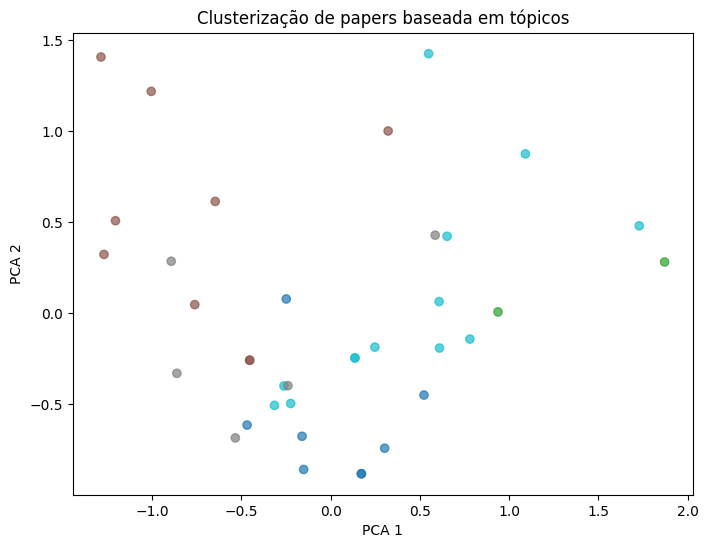

In [102]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(paper_matrix)

plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1], c=df_clean["paper_cluster"], cmap="tab10", alpha=0.7)
plt.title("Clusterização de papers baseada em tópicos")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [67]:
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
print(df_clean)

                                                                                                                                               title  \
0                                                         Supporting Readability by Comprehending the Hierarchical Abstraction of a Software Project   
1                                                                Test2Feature: feature-based test traceability tool for highly configurable software   
2                                                                                                           Executable Multi-Layered Software Models   
3                                                                                 Re-Engineering Microservices into Web-Based Software Product Lines   
4                                                                                  Enhancing Model-Driven Reverse Engineering Using Machine Learning   
5                                                                       An Empirical Stu

In [68]:
for cluster_id, keywords in clusters.items():
    print(f"\nCluster {cluster_id}:")
    for kw in keywords:
        print(f"  - {kw}")


Cluster -1:
  - Human-centered computing
  - Information systems
  - Social and professional topics
  - Professional topics
  - Management of computing and information systems
  - Software creation and management
  - Software post-development issues
  - Software notations and tools
  - Reusability
  - Software product lines
  - Software verification and validation
  - Process validation
  - Traceability
  - Software defect analysis
  - System description languages
  - Applied computing
  - Arts and humanities
  - Computing methodologies
  - Software evolution
  - Software version control
  - Security and privacy
  - Systems security
  - Operating systems security
  - Trusted computing
  - Context specific languages
  - Domain specific languages
  - Education
  - Human computer interaction (HCI)
  - Computing education programs
  - Computer science education
  - Software organization and properties
  - Graph Neural Networks
  - Training Set
  - Gated Recurrent Unit
  - Long Short-term 